In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('/nfs/polizzi/bfry/lab_share/design/nise_pipeline/utils/torch_shape_complementarity/examples/sc_scores.csv')
df

,path,rosetta_sc,our_sc,fwd_sc,rev_sc,n_trimmed_a,n_trimmed_b,n_surface_b,n_buried_b
0,/nfs/polizzi/bfry/programs/CARPdock/apixaban_n...,0.677,0.675700,0.654437,0.696963,7397,5028,5681,5552
1,/nfs/polizzi/bfry/programs/CARPdock/apixaban_n...,0.704,0.698853,0.663295,0.734412,7063,4745,5569,5324
2,/nfs/polizzi/bfry/programs/CARPdock/apixaban_n...,0.647,0.645219,0.609145,0.681293,7405,5177,5523,5473
3,/nfs/polizzi/bfry/programs/CARPdock/apixaban_n...,0.759,0.754289,0.744518,0.764060,6186,4742,5644,5325
4,/nfs/polizzi/bfry/programs/CARPdock/apixaban_n...,0.682,0.677196,0.651045,0.703346,7643,5090,5535,5478
...,...,...,...,...,...,...,...,...,...
2380,/nfs/polizzi/bfry/programs/CARPdock/apixaban_n...,0.708,0.698649,0.674147,0.723150,7207,5199,5558,5512
2381,/nfs/polizzi/bfry/programs/CARPdock/apixaban_n...,0.685,0.680630,0.643711,0.717548,7029,4957,5562,5453
2382,/nfs/polizzi/bfry/programs/CARPdock/apixaban_n...,0.733,0.724579,0.707391,0.741768,6176,4506,5522,5197
2383,/nfs/polizzi/bfry/programs/CARPdock/apixaban_n...,0.708,0.700641,0.681385,0.719898,6522,4532,5462,5212


/tmp/ipykernel_4007509/2051220684.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df_filt, x='our_sc', y='rosetta_sc', c=ga, palette='viridis', legend=False, edgecolor=None, alpha=0.7, ax=ax)


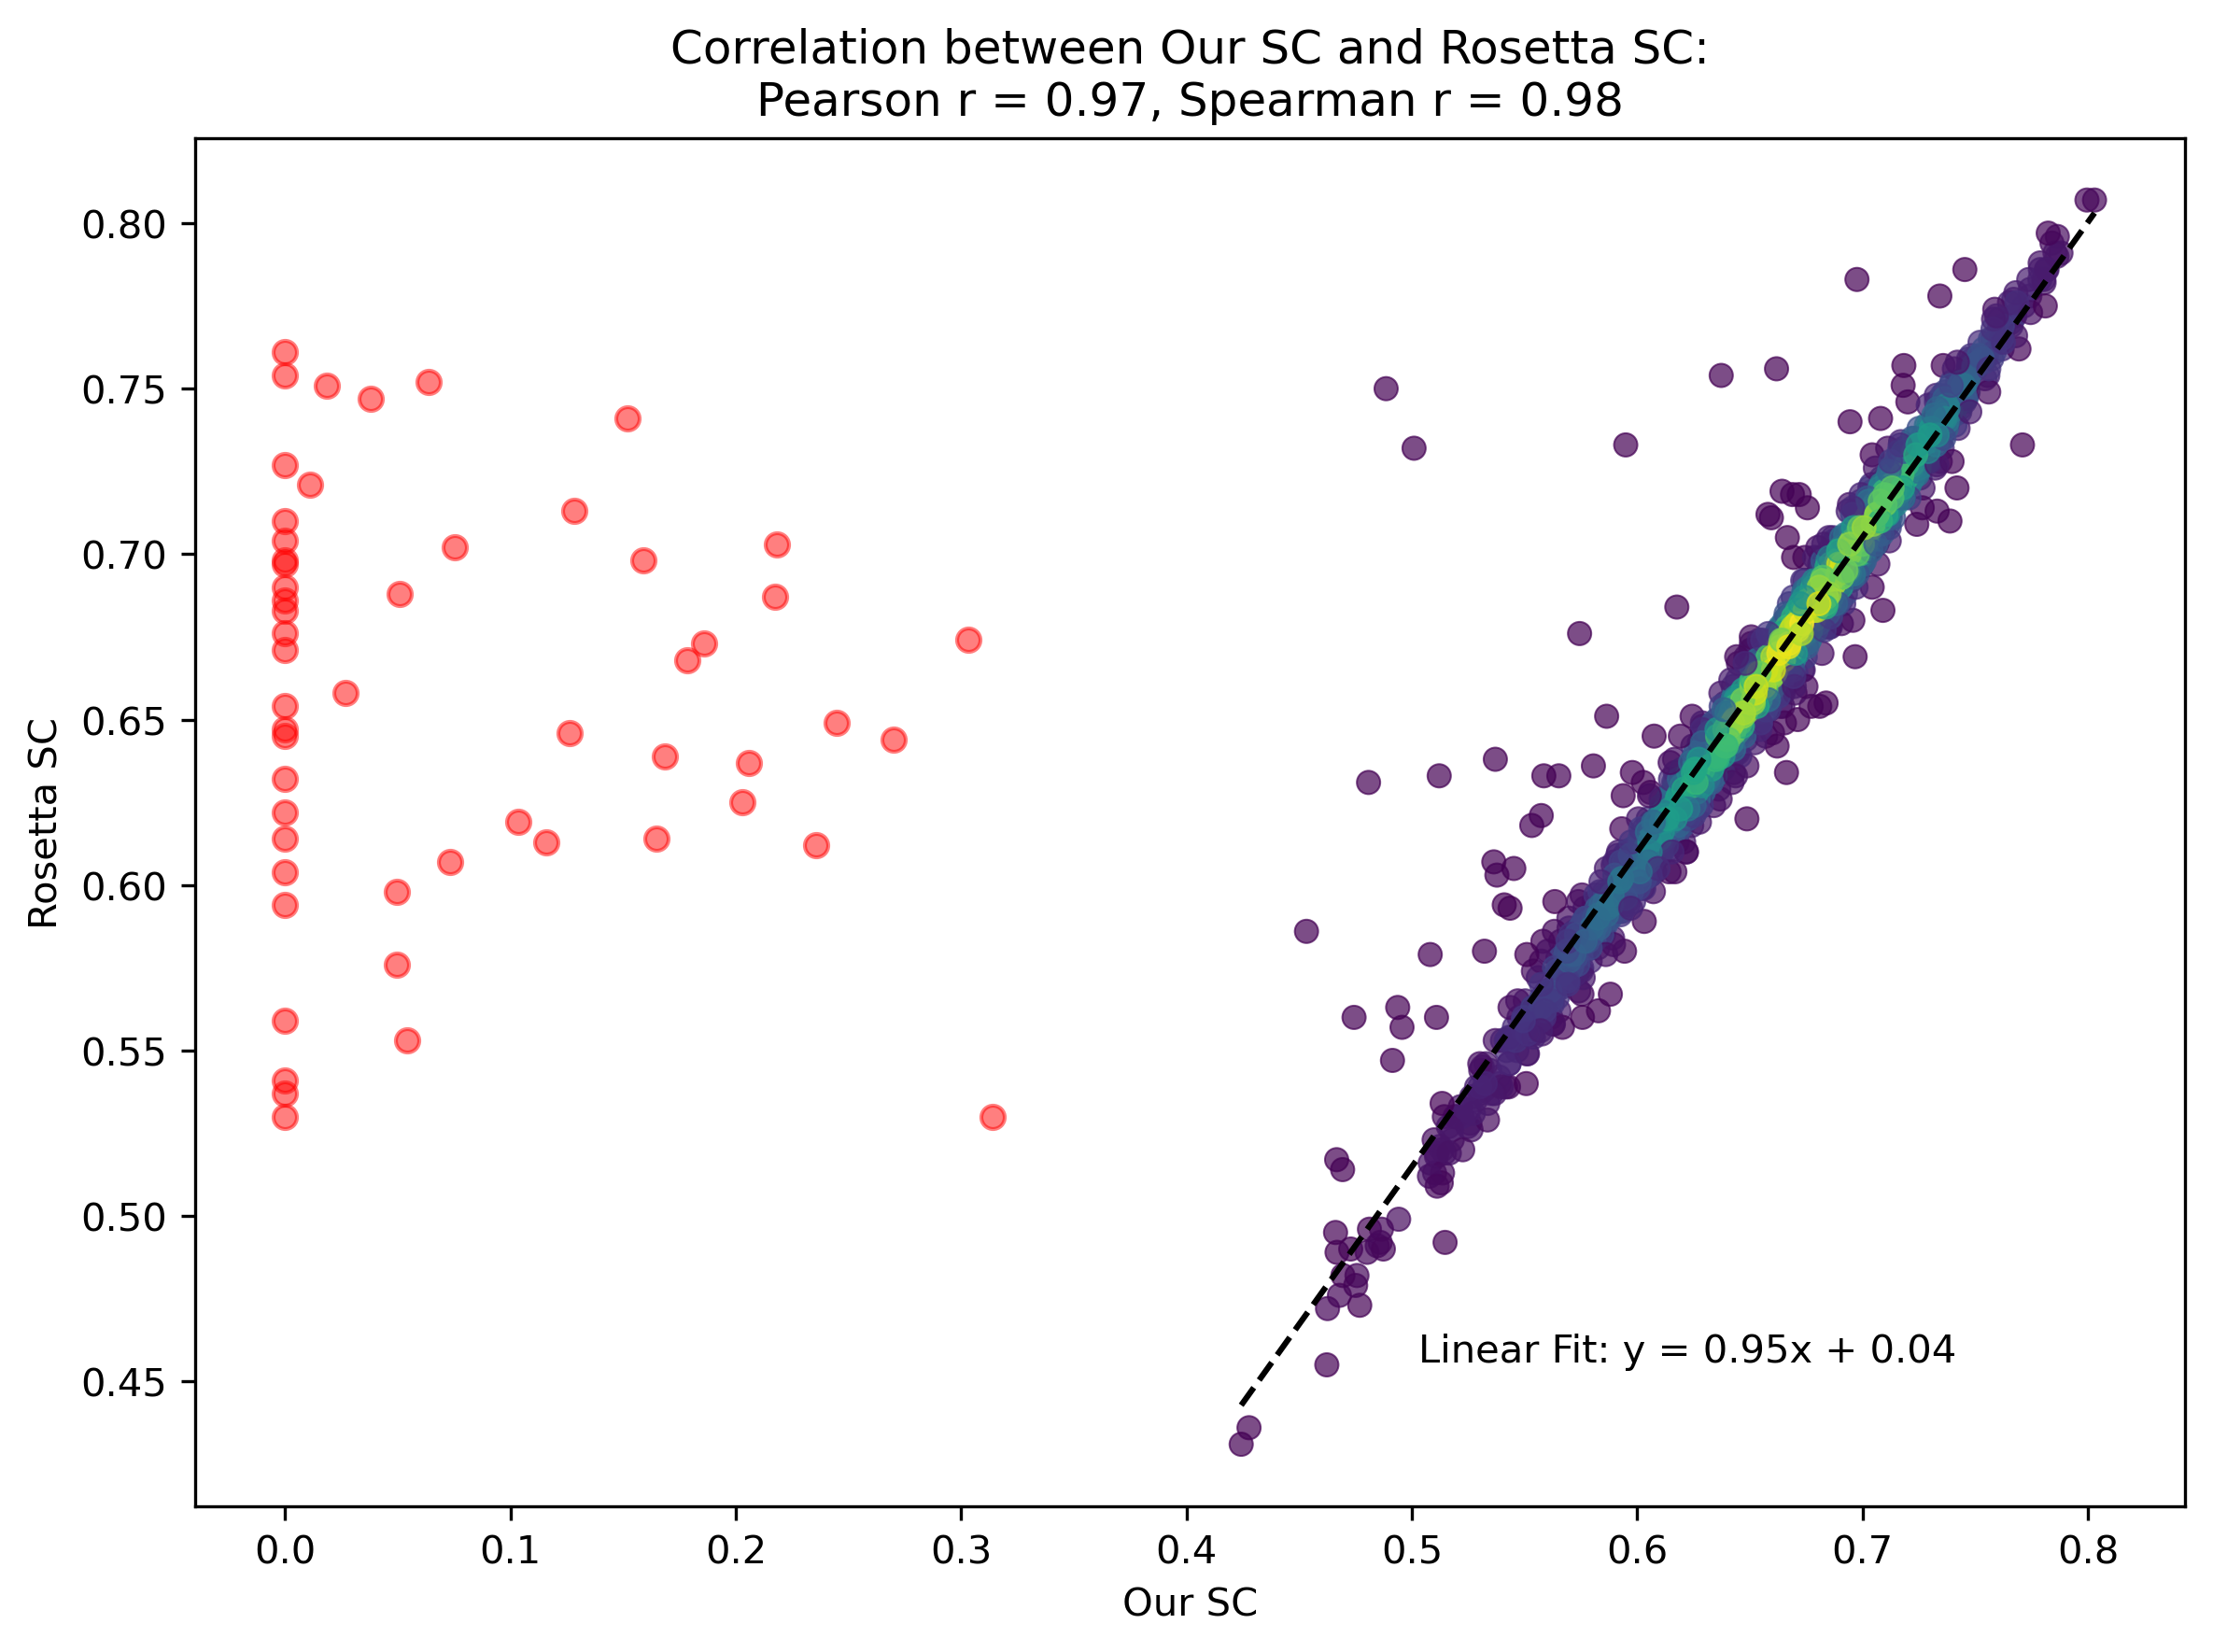

In [45]:
import numpy as np
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from scipy.optimize import curve_fit

df_filt = df[df['our_sc'] > 0.4]


X = df_filt['our_sc']
Y = df_filt['rosetta_sc']
xy = np.vstack([X, Y])
ga = gaussian_kde(xy)(xy)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)


ax.scatter(df[df['our_sc'] < 0.4].our_sc, df[df['our_sc'] < 0.4].rosetta_sc, color='red', alpha=0.5, label='Filtered out')
sns.scatterplot(df_filt, x='our_sc', y='rosetta_sc', c=ga, palette='viridis', legend=False, edgecolor=None, alpha=0.7, ax=ax)
fit, err = curve_fit(lambda x, a, b: a * x + b, df_filt['our_sc'], df_filt['rosetta_sc'])
x_fit = np.linspace(df_filt['our_sc'].min(), df_filt['our_sc'].max(), 100)
y_fit = fit[0] * x_fit + fit[1]
ax.plot(x_fit, y_fit, color='black', linestyle='--', label='Linear Fit')
# print(f'Linear Fit Parameters: a = {fit[0]:.2f}, b = {fit[1]:.2f} (should be close to a=1, b=0 for perfect correlation)')
plt.text(0.75, 0.1, f'Linear Fit: y = {fit[0]:.2f}x + {fit[1]:.2f}', transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='center')

# print(pearsonr(df_filt['our_sc'], df_filt['rosetta_sc']).correlation)
# print(spearmanr(df_filt['our_sc'], df_filt['rosetta_sc']).correlation)

pearson = pearsonr(df_filt['our_sc'], df_filt['rosetta_sc']).correlation
spearman = spearmanr(df_filt['our_sc'], df_filt['rosetta_sc']).correlation # type: ignore

ax.set_xlabel('Our SC')
ax.set_ylabel('Rosetta SC')
ax.set_title('Correlation between Our SC and Rosetta SC:\nPearson r = {pearson:.2f}, Spearman r = {spearman:.2f}'.format(pearson=pearson, spearman=spearman))
fig.tight_layout()